### Can Treasury yield movements help anticipate short-term equity market behavior?

#### Overview:
This analysis uses historical data from FRED (Federal Reserve Economic Data) to look at changes in Treasury yields and find if they contain predictive information about next-day S&P 500 market direction. While the relationship is unlikely to be perfectly deterministic, even modest predictive signals may hold value when incorporated into broader institutional investment strategies.

#### Business Relevance:
Institutional investors and hedge funds constantly monitor macroeconomic indicators to guide investment decisions. If I can find an association between Treasury yields shifts in equity performance or market volatility, firms may be able to improve portfolio risk management or identify favorable market regimes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# now we import the data
sp500 = pd.read_csv("SP500.csv")
dgs10 = pd.read_csv("DGS10.csv")

In [10]:
# start with an initial glance
print(sp500.head())
print(dgs10.head())

  observation_date    SP500
0       2016-05-09  2058.69
1       2016-05-10  2084.39
2       2016-05-11  2064.46
3       2016-05-12  2064.11
4       2016-05-13  2046.61
  observation_date  DGS10
0       2016-05-09   1.77
1       2016-05-10   1.77
2       2016-05-11   1.73
3       2016-05-12   1.75
4       2016-05-13   1.71


They both start at the same date and end at the same date, which means I imported the datasets with the correct ranges. There are a few null values, though, that I need to clean up.

In [11]:
# let's start by renaming the columns
sp500.columns = ["DATE", "SP500"]
dgs10.columns = ["DATE", "DGS10"]
print(sp500.head())
print(dgs10.head())

         DATE    SP500
0  2016-05-09  2058.69
1  2016-05-10  2084.39
2  2016-05-11  2064.46
3  2016-05-12  2064.11
4  2016-05-13  2046.61
         DATE  DGS10
0  2016-05-09   1.77
1  2016-05-10   1.77
2  2016-05-11   1.73
3  2016-05-12   1.75
4  2016-05-13   1.71


In [14]:
# converting the dates and values so Python understands that 
# they aren't just strings of text
sp500["DATE"] = pd.to_datetime(sp500["DATE"])
dgs10["DATE"] = pd.to_datetime(dgs10["DATE"])

sp500["SP500"] = pd.to_numeric(sp500["SP500"], errors="coerce")
dgs10["DGS10"] = pd.to_numeric(dgs10["DGS10"], errors="coerce")

In [ ]:
# now we can merge the datasets using the date!
df = pd.merge(sp500, dgs10, on="DATE", how="inner")
print(df.head())

        DATE    SP500  DGS10
0 2016-05-09  2058.69   1.77
1 2016-05-10  2084.39   1.77
2 2016-05-11  2064.46   1.73
3 2016-05-12  2064.11   1.75
4 2016-05-13  2046.61   1.71


In [18]:
# with a merged dataset we can drop the null values
df = df.dropna()

print(df.head())

# and then confirm that there are no more nulls
print(df.isnull().sum())

        DATE    SP500  DGS10
0 2016-05-09  2058.69   1.77
1 2016-05-10  2084.39   1.77
2 2016-05-11  2064.46   1.73
3 2016-05-12  2064.11   1.75
4 2016-05-13  2046.61   1.71
DATE     0
SP500    0
DGS10    0
dtype: int64


#### Feature Engineering

To look at this relationship between interest rate movements and equity market behavior, I am going to create new variables that will help measure "movement."

Daily S&P 500 returns will be calculated to track short-term market performance, and daily Treasury yield changes will be used to show shifts in the interest rate environment.

I am also going to add a binary prediction target to determine whether the market moved up (1) or down (0) on the following trading day. 

In [20]:
# this will calculate daily S&P returns
df["SP500_Return"] = df["SP500"].pct_change()

# and this will track daily changes in treasury yields
df["Yield_Change"] = df["DGS10"].diff()

print(df.head())

        DATE    SP500  DGS10  SP500_Return  Yield_Change  Next_Day_Positive
1 2016-05-10  2084.39   1.77           NaN           NaN                  0
2 2016-05-11  2064.46   1.73     -0.009562         -0.04                  0
3 2016-05-12  2064.11   1.75     -0.000170          0.02                  0
4 2016-05-13  2046.61   1.71     -0.008478         -0.04                  1
5 2016-05-16  2066.66   1.75      0.009797          0.04                  0


In [21]:
# now for the prediction target
# 1 = market goes up next day
# 0 = market goes down next day

df["Next_Day_Positive"] = (
    df["SP500_Return"].shift(-1) > 0
).astype(int)

# removing empty rows that were created during the calculations
df = df.dropna()

print(df.head())

        DATE    SP500  DGS10  SP500_Return  Yield_Change  Next_Day_Positive
2 2016-05-11  2064.46   1.73     -0.009562         -0.04                  0
3 2016-05-12  2064.11   1.75     -0.000170          0.02                  0
4 2016-05-13  2046.61   1.71     -0.008478         -0.04                  1
5 2016-05-16  2066.66   1.75      0.009797          0.04                  0
6 2016-05-17  2047.21   1.76     -0.009411          0.01                  1


#### Exploratory Data Analysis

Now we can look at:
- how the stock market and Treasury yields changed over time,
- whether yield changes appear related to market returns,
- and whether the relationship shows meaningful patterns that may hold predictive value.

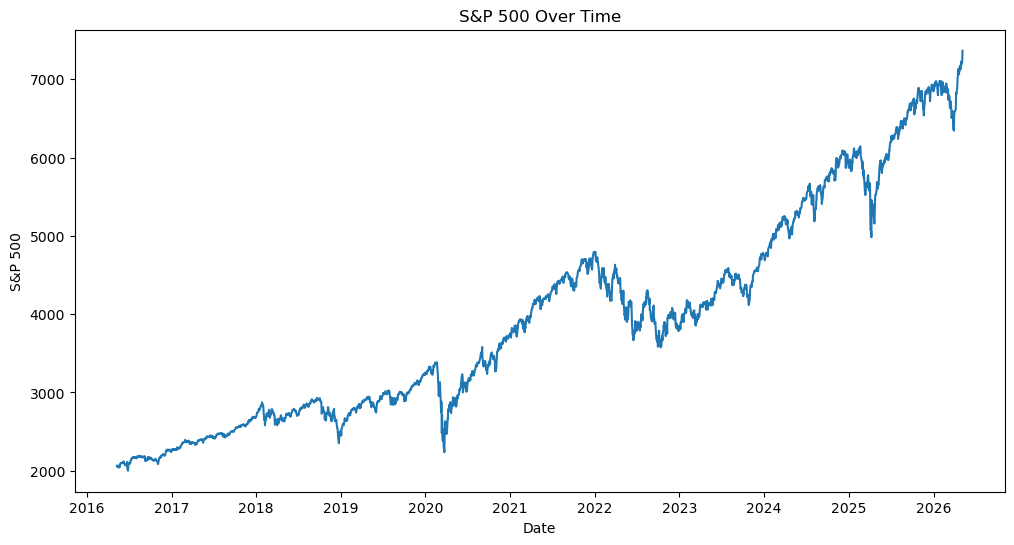

In [ ]:
# plotting S&P 500 over time
plt.figure(figsize=(12,6))

plt.plot(df["DATE"], df["SP500"])

plt.title("S&P 500 Over Time")
plt.xlabel("Date")
plt.ylabel("S&P 500")

plt.show()

Looks good! We can see the COVID crash, post-COVID growth, 2022 dip, and a strong recovery since.

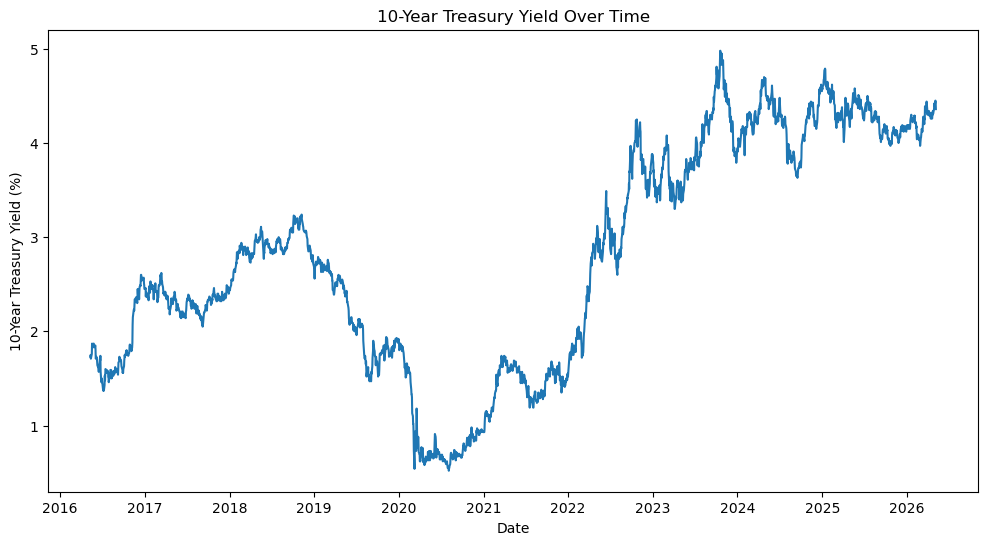

In [ ]:
# now for the 10-Year Treasury Yield over time
plt.figure(figsize=(12,6))

plt.plot(df["DATE"], df["DGS10"])

plt.title("10-Year Treasury Yield Over Time")
plt.xlabel("Date")
plt.ylabel("10-Year Treasury Yield (%)")

plt.show()

Looks great as well; we can see the low yields during COVID, the sharp rise during inflation and the Federal hikes, and how volitile it has been since 2021.

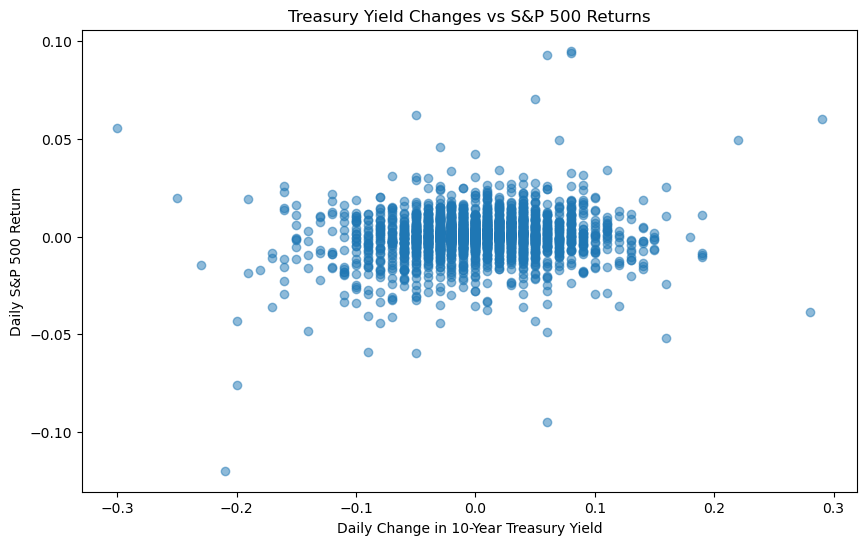

In [ ]:
# scatterplot of yield changes vs market returns
plt.figure(figsize=(10,6))

plt.scatter(
    df["Yield_Change"],
    df["SP500_Return"],
    alpha=0.5
)

plt.title("Treasury Yield Changes vs S&P 500 Returns")
plt.xlabel("Daily Change in 10-Year Treasury Yield")
plt.ylabel("Daily S&P 500 Return")

plt.show()

This shows the relationship between yield changes and market returns. Each dot represents one trading day, with the x-axis explaining how much yeilds changed, and the y-axis displaying how much the stock market moved.

There is lots of noise, and most points are centered around 0. This makes sense, as market returns are influenced by a variety of things, so the relationship won't be super clear. There could still be some type of underlying conneciton, though.

In [ ]:
# time to calculate correlation
correlation = df["Yield_Change"].corr(df["SP500_Return"])

print("Correlation:", correlation)

Correlation: 0.12553668958838896


We found a low positive correlation, which is very interesting. This suggests that during my dataset's time frame, increases in Treasury yields were slightly associated with positive S&P 500 returns. 

This indicates that rising yields may sometimes coincide with periods of economic optimism and stronger market performance.

#### Predictive Modeling
Now I am going to investigate whether movements in Tresury yields can contain short-term predictive information. The model will attempt to predict whether the S&P will close positive or negative on the following trade day. 

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [28]:
# input feature (X)
X = df[["Yield_Change"]]

# target variable (y)
y = df["Next_Day_Positive"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)
# following the 80/20 split!

In [31]:
# creating and training the model
model = LogisticRegression()
model.fit(X_train, y_train)

# making predictions and calculating the accuracy
y_prediction = model.predict(X_test)

accuracy = accuracy_score(y_test, y_prediction)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5370741482965932


The predictive model achieved an accuracy of ~53.7%. This is modest, but it does suggest that changes in treasury yields can contain small amounts of informational value when looking at short-term market behavior. 